In [3]:
# =============================================================================
# HEART DISEASE PREDICTION: STUDENT 3 ANALYSIS (ENSEMBLE METHODS)
# =============================================================================
# 1. 10 Strategic & Unique EDA Visualizations (Direct Display)
# 2. Imbalance Handling: Manual Random Oversampling
# 3. Model Training: AdaBoost & Gradient Boosting
# 4. Professional Evaluation & Algorithm Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings

# --- Global Style Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="white", palette="bright")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# -----------------------------------------------------------------------------
# STEP 1: DATA LOADING & PREPARATION
# -----------------------------------------------------------------------------
try:
    df = pd.read_csv('heart.csv')

    # Identify Categorical Columns
    cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

    print("✓ Heart dataset loaded for Student 3.")
except Exception as e:
    print(f"Error: {e}")

✓ Heart dataset loaded for Student 3.


In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


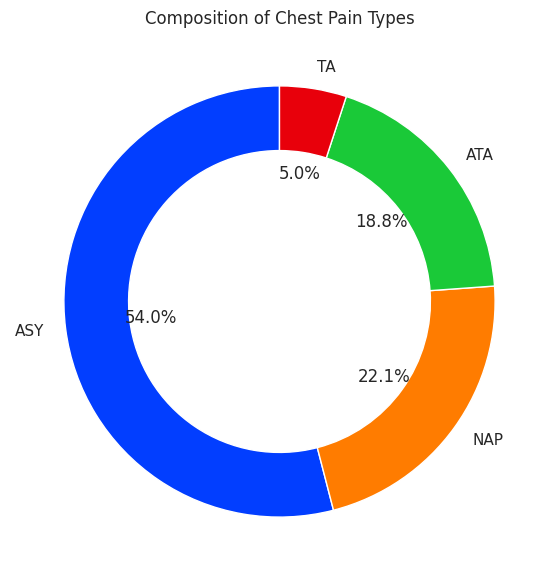

In [8]:
# 1. Donut Chart: Chest Pain Type Distribution
plt.figure(figsize=(7,7))
df['ChestPainType'].value_counts().plot.pie(autopct='%1.1f%%', wedgeprops=dict(width=0.3), startangle=90)
plt.title('Composition of Chest Pain Types')
plt.ylabel('')
plt.show()

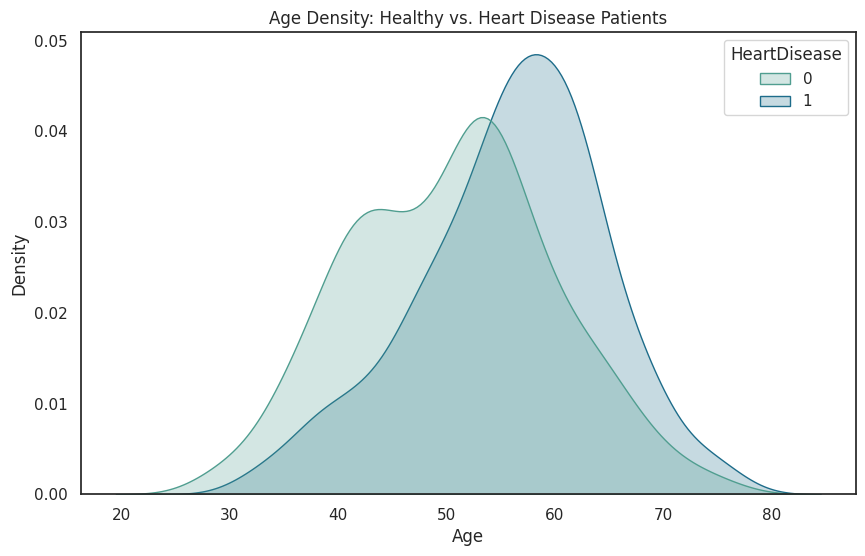

In [9]:
plt.figure()
sns.kdeplot(data=df, x='Age', hue='HeartDisease', fill=True, common_norm=False, palette='crest')
plt.title('Age Density: Healthy vs. Heart Disease Patients')
plt.show()

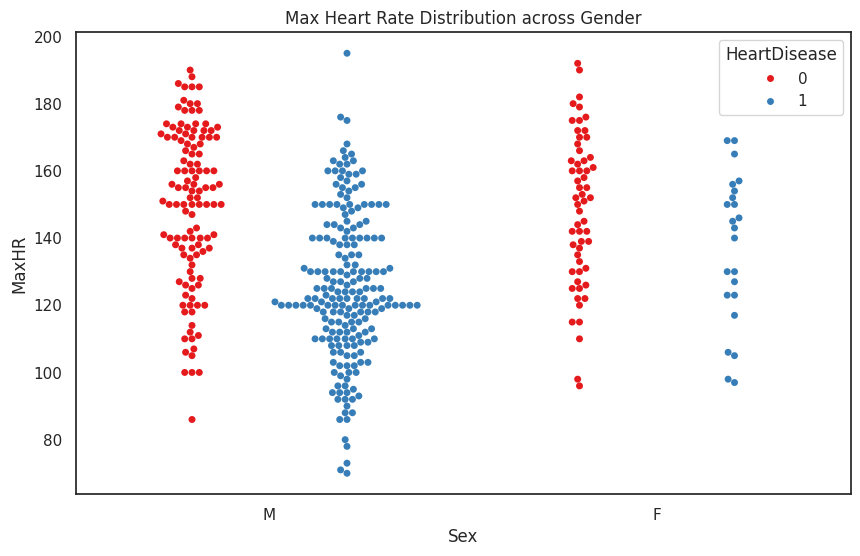

In [10]:
# 3. Swarm Plot: Max Heart Rate by Gender and Disease
plt.figure()
sns.swarmplot(x='Sex', y='MaxHR', hue='HeartDisease', data=df.sample(400), palette='Set1', dodge=True)
plt.title('Max Heart Rate Distribution across Gender')
plt.show()

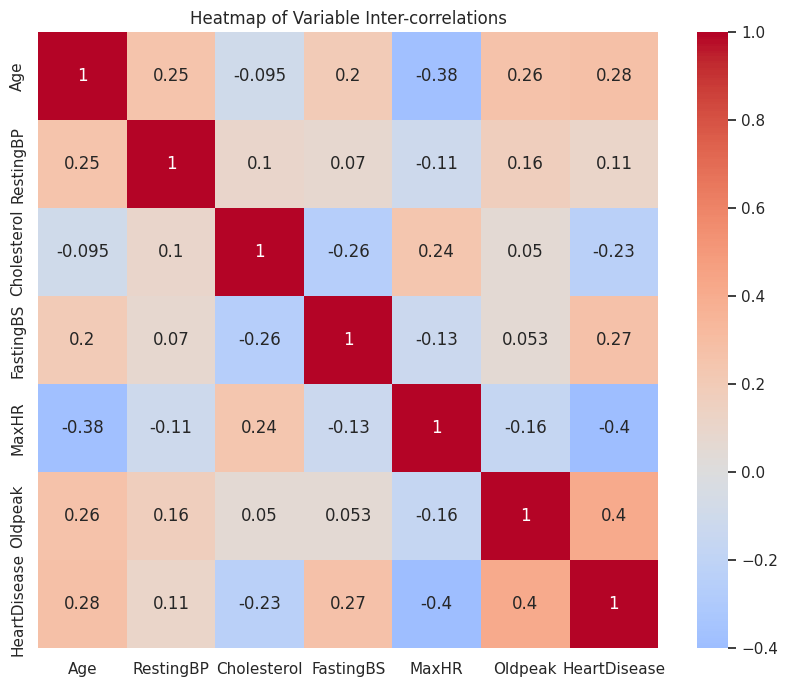

In [11]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap of Variable Inter-correlations')
plt.show()

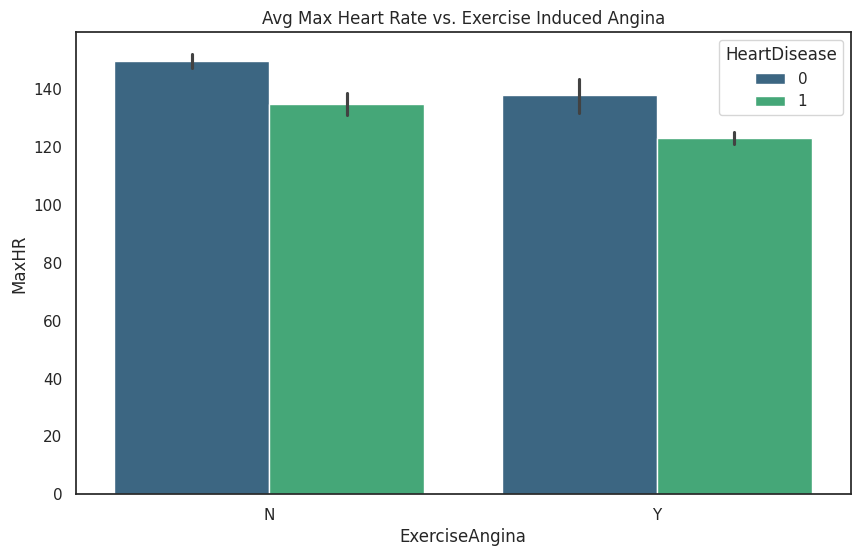

In [13]:
plt.figure()
sns.barplot(x='ExerciseAngina', y='MaxHR', hue='HeartDisease', data=df, palette='viridis')
plt.title('Avg Max Heart Rate vs. Exercise Induced Angina')
plt.show()

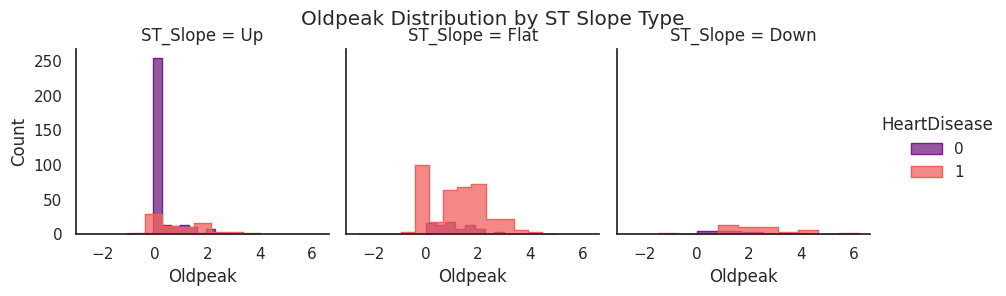

In [14]:
g = sns.FacetGrid(df, col="ST_Slope", hue="HeartDisease", palette='magma')
g.map(sns.histplot, "Oldpeak", element="step")
g.add_legend()
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Oldpeak Distribution by ST Slope Type')
plt.show()

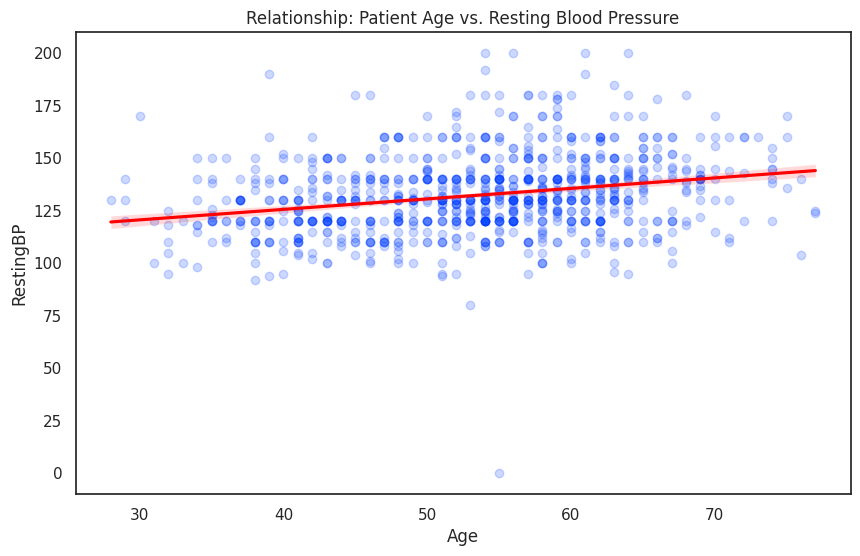

In [15]:
plt.figure()
sns.regplot(x='Age', y='RestingBP', data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Relationship: Patient Age vs. Resting Blood Pressure')
plt.show()

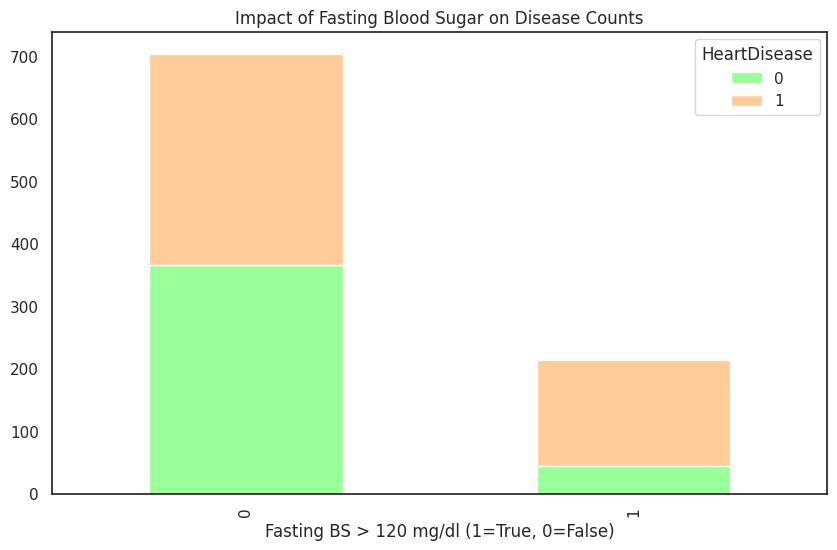

In [16]:
df_fasting = df.groupby(['FastingBS', 'HeartDisease']).size().unstack()
df_fasting.plot(kind='bar', stacked=True, color=['#99ff99','#ffcc99'])
plt.title('Impact of Fasting Blood Sugar on Disease Counts')
plt.xlabel('Fasting BS > 120 mg/dl (1=True, 0=False)')
plt.show()

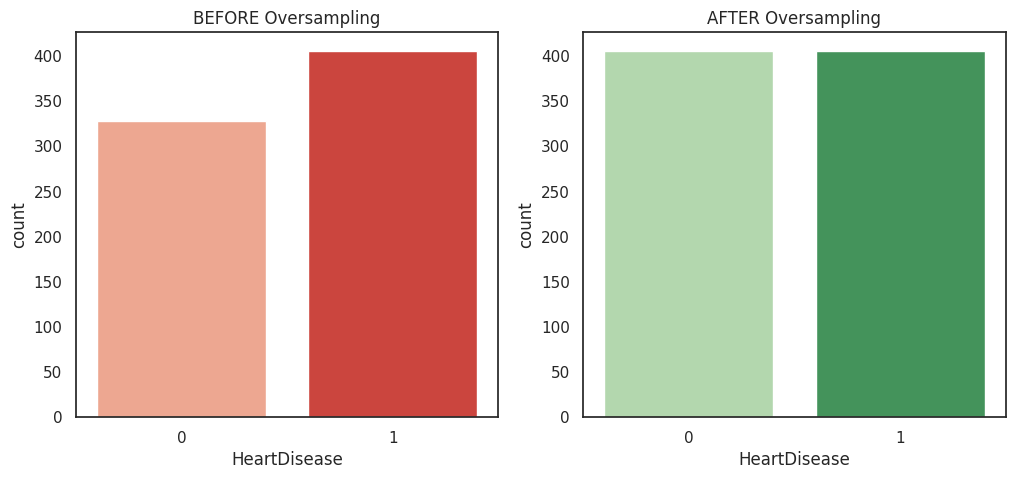

In [17]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & OVERSAMPLING
# -----------------------------------------------------------------------------
# Encoding Categorical Variables
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features and Target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split first (80/20)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Manual Oversampling (Ensuring balanced classes)
train_data = pd.concat([X_train_raw, y_train_raw], axis=1)
df_maj = train_data[train_data.HeartDisease == 1]
df_min = train_data[train_data.HeartDisease == 0]

df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

# Visualizing Balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='HeartDisease', data=train_data, ax=ax1, palette='Reds')
ax1.set_title('BEFORE Oversampling')
sns.countplot(x='HeartDisease', data=train_balanced, ax=ax2, palette='Greens')
ax2.set_title('AFTER Oversampling')
plt.show()

X_train = train_balanced.drop('HeartDisease', axis=1)
y_train = train_balanced['HeartDisease']

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

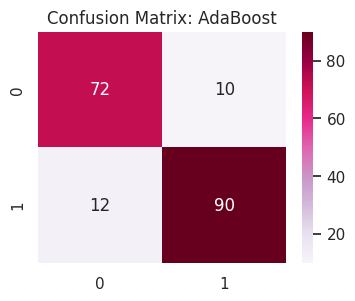

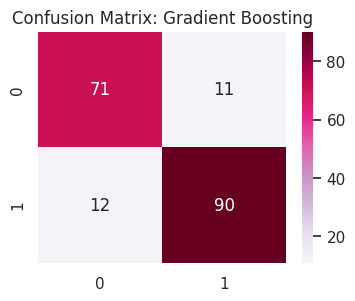

In [18]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (ADABOOST & GRADIENT BOOSTING)
# -----------------------------------------------------------------------------
models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4)
    })

    # Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='PuRd')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

In [19]:
# -----------------------------------------------------------------------------
# STEP 5: PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*60)
print("STUDENT 3: HEART DISEASE PERFORMANCE RANK TABLE")
print("="*60)
print(rank_table)


STUDENT 3: HEART DISEASE PERFORMANCE RANK TABLE
              Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                          
1              AdaBoost    0.8804     0.9000  0.8824    0.8911
2     Gradient Boosting    0.8750     0.8911  0.8824    0.8867


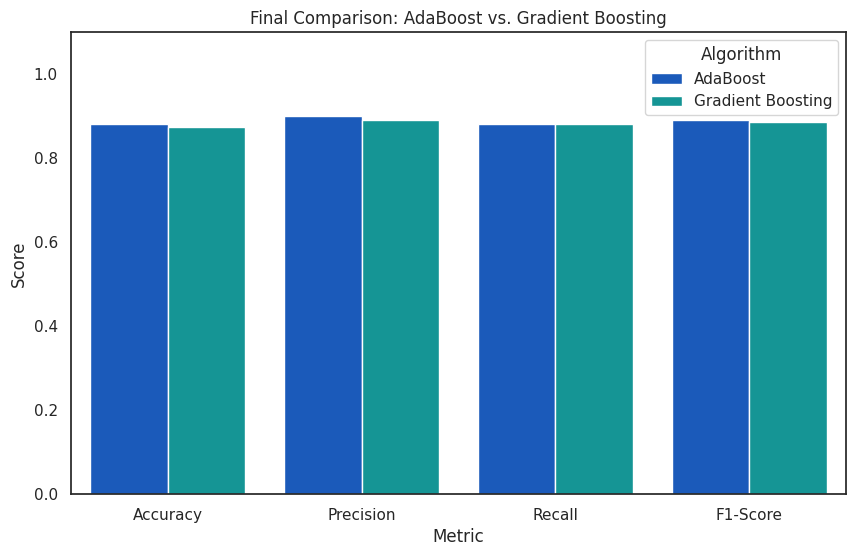

In [20]:
# Visual Metric Comparison
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted, palette='winter')
plt.title('Final Comparison: AdaBoost vs. Gradient Boosting')
plt.ylim(0, 1.1)
plt.show()